№4 (6 баллов)
Проведите всесторонний анализ и визуализацию данных. Пользуйтесь
https://cloud.mail.ru/public/A8ie/9dJHy8iHo, материалами лекции и другими доступными
источниками.
1. Используя ресурс kaggle (https://www.kaggle.com/), выберите один из наборов данных. Загрузите этот набор и выведите первые 10 записей на экран.


https://www.kaggle.com/datasets/wardabilal/spotify-global-music-dataset-20092025

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
from matplotlib import pyplot as plt

df = pd.read_csv("spotify_data_cl.csv")
df.head(10)

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39
5,4ccpCcZYseq8VrPMK1EDs0,BLEED,1,2,False,Minzie,46,7218,dark r&b,2NQv9p3ZQW0Ed1LB9enix8,BLEED,2025-10-30,3,single,2.76
6,3QoQ3HqXTAjgEl9LbNMbYp,Te Procuro na Cidade,1,20,False,AZERDK,30,1657,NaN,1PpuOsLjPWshDLxkr0oHeU,Te Procuro na Cidade,2025-10-30,1,single,4.12
7,1YEZbdT417SfolPQzaoHs2,come closer,1,27,False,Rumelis,49,8802,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.53
8,4pZ949nFW5SurwzE0TSe7I,Cupido Vagabundo,1,16,False,Toni dos Anjos,6,475,NaN,60DLQZkzpvDvVfvEC6VOJM,Cupido Vagabundo,2025-10-30,2,single,2.92
9,0L0LgwFZ7UtBnRNQvSBty6,LET’S GO!,1,33,True,PsychoYP,48,154802,"nigerian drill, alté, afro adura, afrobeats, a...",3ARxksm8CspGeAaZZB1v2w,LET’S GO!,2025-10-28,1,single,2.40



2. Опишите данные набора: какие признаки в нем присутствуют, что они означают,
какой у них тип данных, какие значения могут принимать.


In [2]:
desc = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(t) for t in df.dtypes],
    "missing": df.isna().sum().values,
    "missing_%": (df.isna().mean() * 100).round(2).values,
    "unique": df.nunique(dropna=True).values,
    "examples": [df[c].dropna().astype(str).head(3).tolist() for c in df.columns],
})
desc

,column,dtype,missing,missing_%,unique,examples
0,track_id,object,0,0.00,8582,"[3EJS5LyekDim1Tf5rBFmZl, 1oQW6G2ZiwMuHqlPpP27D..."
1,track_name,object,0,0.00,7462,"[Trippy Mane (ft. Project Pat), OMG!, Hard 2 F..."
2,track_number,int64,0,0.00,54,"[4, 1, 1]"
3,track_popularity,int64,0,0.00,98,"[0, 0, 4]"
4,explicit,bool,0,0.00,2,"[True, True, True]"
5,artist_name,object,3,0.03,2547,"[Diplo, Yelawolf, Riff Raff]"
6,artist_popularity,int64,0,0.00,96,"[77, 64, 48]"
7,artist_followers,int64,0,0.00,3740,"[2812821, 2363438, 193302]"
8,artist_genres,object,3361,39.16,661,"[moombahton, country hip hop, southern hip hop..."
9,album_id,object,0,0.00,5205,"[5QRFnGnBeMGePBKF2xTz5z, 4SUmmwnv0xTjRcLdjczGg..."


In [ ]:
"""
track_id — уникальный идентификатор трека.
track_name — название композиции.
track_number — порядковый номер трека в альбоме.
track_popularity — показатель популярности трека.
explicit — признак того, что в тексте есть откровенный или нецензурный контент.
artist_name — имя исполнителя.
artist_followers — количество подписчиков исполнителя.
artst_genres — музыкальные жанры, в которых работает исполнитель.
album_id — уникальный идентификатор альбома.
album_name — название альбома.
album_release_date — дата релиза альбома.
album_total_tracks — сколько всего треков входит в альбом.
album_type — вид альбома (например, сингл, мини‑альбом, полноформатный альбом).
track_duration_min — длительность трека, выраженная в минутах.
"""

3. Укажите какие признаки являются количественными, качественными порядковыми
и качественными номинальными.


In [ ]:
"""
Количественные признаки

Это переменные, которые измеряются числами и с которыми можно выполнять арифметические операции

track_number — номер трека в альбоме, целое число
track_popularity — числовой показатель популярности трека
artist_popularity — числовая оценка популярности исполнителя
artist_followers — счётчик подписчиков исполнителя
album_total_tracks — количество треков в альбоме
track_duration_min — продолжительность трека в минутах
"""

In [ ]:
"""
Качественные порядковые

В явном виде таких признаков здесь практически нет; возможен лишь условный порядок

track_number можно интерпретировать как порядковый только внутри одного альбома (1‑й, 2‑й трек и т.д.)
album_release_date задаёт упорядоченную временную шкалу, но это скорее отдельный временной тип, 
а не классический качественный признак
track_popularity и artist_popularity можно превратить в порядковые признаки, если 
заранее разбить значения на категории уровней (низкая, средняя, высокая популярность)
"""

In [ ]:
"""
Качественные номинальные

Это категориальные признаки, у которых нет естественного порядка значений

track_id — идентификатор трека
track_name — название трека
artist_name — имя исполнителя
artist_genres — жанры исполнителя, отражающие тип музыки без порядка
album_id — идентификатор альбома
album_name — название альбома
album_type — вид альбома (например, album, single и т.п.)
explicit — бинарный признак наличия откровенного/цензурного контента (“да/нет”)
"""

4. Рассчитайте параметры описательной статистики для признаков набора. С помощью
параметров описательной статистики опишите один из количественных признаков и
один из категориальных признаков. Есть ли в количественном признаке выбросы?
Какое значение является выбросом и почему? По какому категориальному признаку
можно группировать данные? Какие группировки представляют интерес и почему?


In [3]:
# Количественные признаки

num_cols = ["track_popularity", "artist_popularity", "artist_followers",
            "album_total_tracks", "track_duration_min", "track_number"]
df[num_cols].describe()

,track_popularity,artist_popularity,artist_followers,album_total_tracks,track_duration_min,track_number
count,8582.000000,8582.000000,8.582000e+03,8582.000000,8582.000000,8582.000000
mean,52.356211,69.730016,2.403472e+07,13.789443,3.492805,5.772547
std,23.816076,19.645979,3.803180e+07,11.887131,1.057970,6.052792
min,0.000000,0.000000,0.000000e+00,1.000000,0.070000,1.000000
25%,39.000000,60.000000,4.623200e+05,6.000000,2.880000,1.000000
50%,58.000000,74.000000,6.105547e+06,13.000000,3.445000,4.000000
75%,71.000000,84.000000,2.725255e+07,17.000000,3.990000,9.000000
max,99.000000,100.000000,1.455421e+08,181.000000,13.510000,102.000000


In [5]:
# Категориальные признаки

cat_cols = ["explicit", "album_type", "artist_genres", "track_name", "artist_name"]
df[cat_cols].describe(include="all")

,explicit,album_type,artist_genres,track_name,artist_name
count,8582,8582,5221,8582,8579
unique,2,3,661,7462,2547
top,False,album,soundtrack,Home,Taylor Swift
freq,6434,5856,345,8,324


In [ ]:
# Один из количественных

df["artist_popularity"].describe()

count    8582.000000
mean       69.730016
std        19.645979
min         0.000000
25%        60.000000
50%        74.000000
75%        84.000000
max       100.000000
Name: artist_popularity, dtype: float64

In [7]:
# Один из категориальных

df["album_type"].describe()

count      8582
unique        3
top       album
freq       5856
Name: album_type, dtype: object

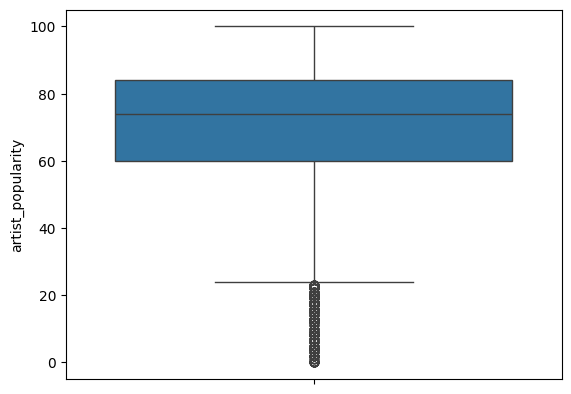

In [8]:
ax = sb.boxplot(data=df, y="artist_popularity")

In [ ]:
"""
Выбросы в нижней квантиле

Ящик с усами (boxplot) — удобный способ наглядно показать выбросы в данных.
​
При построении такого графика границы усов автоматически вычисляются по правилу: 
от первого и третьего квартилей откладывается 1.5 интерквартильного размаха в 
каждую сторону. Всё, что попадает за пределы этих усов, считается выбросами и 
отображается отдельными точками

Данные можно группировать по explicit (true/false категории), 
по album_type (album/single/compilation)

Интересным вариантом выглядела бы ручная группировка не по категориальным, а по 
количественным признакам, например по популярности. Можно заранее разбить артистов 
на несколько уровней (низкая, средняя, высокая популярность) и затем анализировать, 
какая доля попадает в каждую группу. Такой подход позволяет оценить, сколько 
действительно популярных исполнителей существует и как распределяется аудитория, 
по аналогии с тем, как говорят о доле самых богатых людей в мире 
(0.5% населения и т.п.).
"""

5. Постройте графики для количественных и категориальных признаков. 


Какие
визуализации построены для количественных признаков?

In [ ]:
"""
В нашем случае строим гистограмму и ящик с усами 
"""

 Какие особенности
распределения данных они позволяют наблюдать? 

<Axes: xlabel='track_popularity', ylabel='Count'>

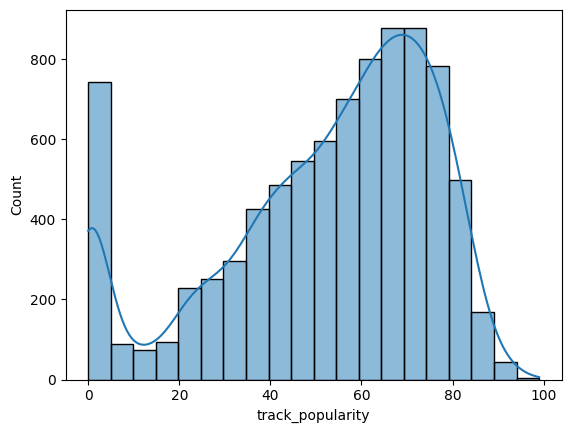

In [9]:
sb.histplot(data=df, x="track_popularity", bins=20, kde=True)

<Axes: ylabel='track_popularity'>

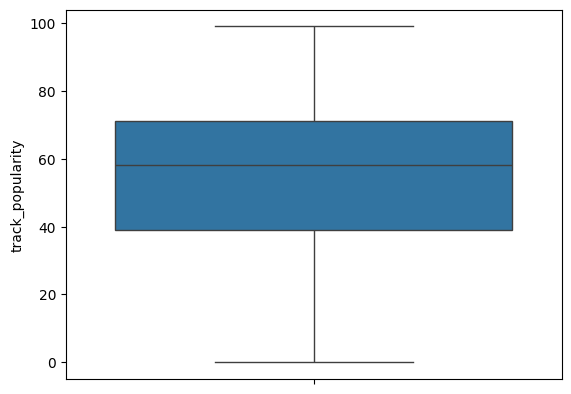

In [10]:
sb.boxplot(data=df, y="track_popularity")

Какие визуализации построены
для категориальных признаков? 

Какие особенности распределения данных они
позволяют наблюдать? 

In [ ]:
"""
Особенности распределения: заметно, что большинство треков либо совсем непопулярны, либо имеют 
средний уровень популярности в диапазоне примерно 50–80, с концентрацией около 60

Для категориальных признаков построены графики частот категорий, которые позволяют 
увидеть дисбаланс классов и понять, какие значения встречаются значительно чаще остальных
"""

<Axes: xlabel='explicit', ylabel='count'>

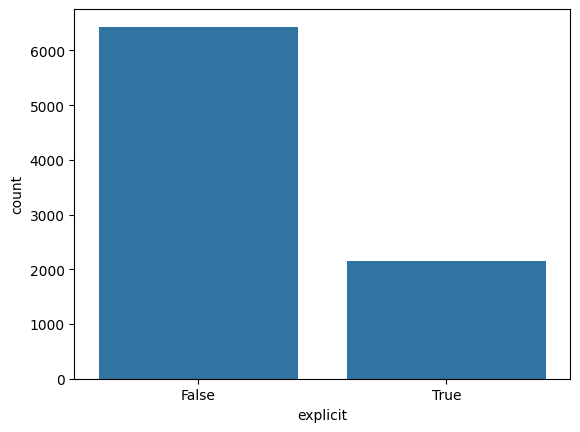

In [11]:
sb.countplot(data=df, x="explicit")

<Axes: xlabel='album_type', ylabel='count'>

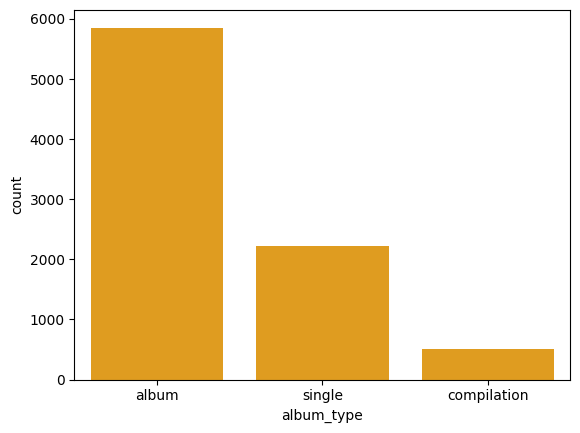

In [12]:
sb.countplot(data=df, x="album_type", color='orange')

Какие визуализации построены для пар признаков? 

Какие
особенности распределения данных они позволяют наблюдать?

In [14]:
"""
Cоотношение числа подписчиков исполнителя и популярности треков

Видим, что корреляция не линейна
"""

'\nCоотношение числа подписчиков исполнителя и популярности треков\n\nВидим, что корреляция не линейна\n'

<Axes: xlabel='artist_followers', ylabel='track_popularity'>

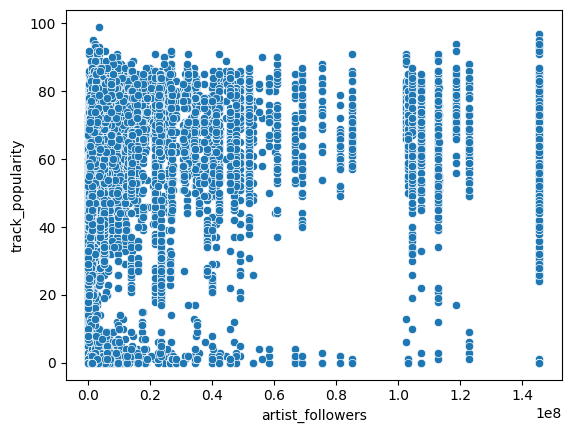

In [15]:
sb.scatterplot(data=df, x="artist_followers", y="track_popularity")

<Axes: xlabel='explicit', ylabel='track_popularity'>

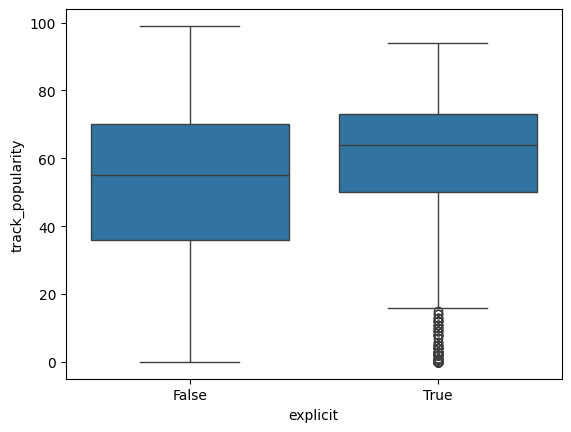

In [16]:
sb.boxplot(data=df, x="explicit", y="track_popularity")

6. Проведите корреляционный анализ. Есть ли в вашем наборе данных коррелирующие
признаки?

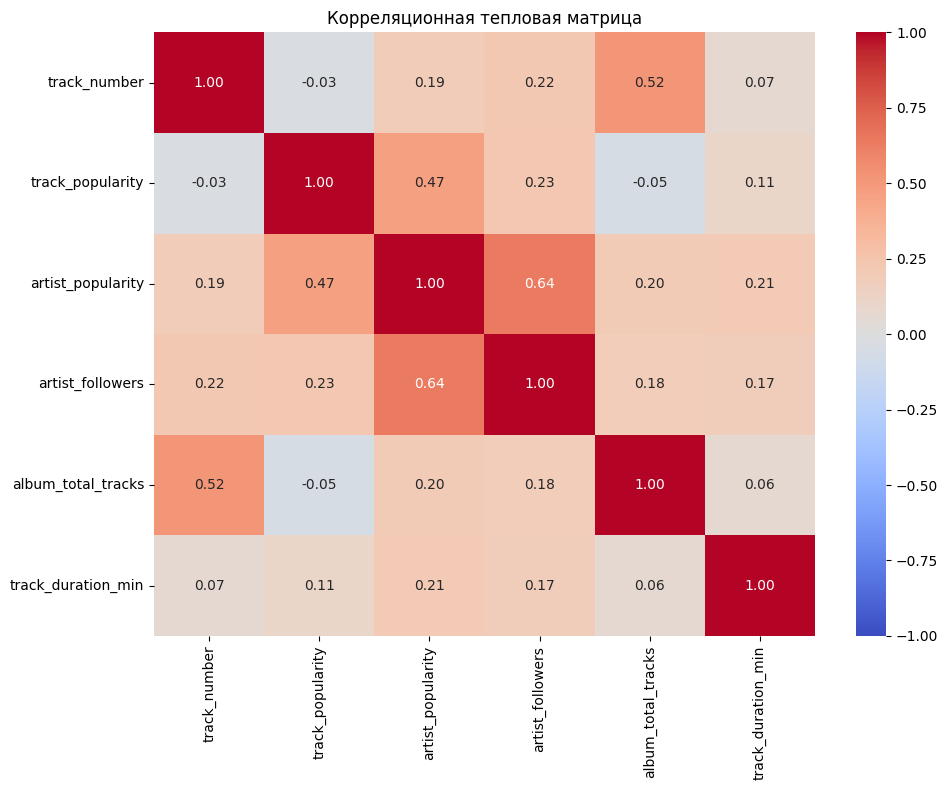

In [ ]:
num = df.select_dtypes(include="number")
corr = num.corr(method="pearson")   # / "spearman"

plt.figure(figsize=(10, 8))
sb.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Корреляционная матрица")
plt.tight_layout()
plt.show()

In [ ]:
"""
Популярность артиста связана с популярностью его треков: 
чем выше известность исполнителя, тем, как правило, популярнее его композиции.

Число подписчиков исполнителя связано с его популярностью: 
более популярные артисты, как правило, имеют больше подписчиков.

Общее количество треков в альбоме ожидаемо связано с номером трека, 
поскольку эти показатели фактически описывают одну и ту же 
структуру альбома (позицию трека внутри набора).
"""